# Email Spam Detection Using Naive Bayes Algorithm

In [20]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, auc, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
# Remove stop words (e.g., “the,” “and”)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Data Loading

In [22]:
# Laod Dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## Data Preprocessing

In [24]:
columns_to_concat = ['v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
df['Email'] = df[columns_to_concat].fillna('').astype(str).agg(' '.join, axis=1)
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,Email
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
# Drop unnecessary columns
df2 = df.drop(['v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df2.head()

,v1,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df2.shape

(5572, 2)

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   Email   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [28]:
# check missing values
df2.isna().sum()

v1       0
Email    0
dtype: int64

In [29]:
df2.dropna(inplace=True)
df2.head()

,v1,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
# rename columns for better understanding
df2 = df2.rename(columns={'v1': 'Label'})
df2.head()

,Label,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
# Label Transformation
df2['Label'] = df2['Label'].map({'ham': "Good Mail", 'spam': "Spam"})
df2.head()

,Label,Email
0,Good Mail,"Go until jurong point, crazy.. Available only ..."
1,Good Mail,Ok lar... Joking wif u oni...
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,Good Mail,U dun say so early hor... U c already then say...
4,Good Mail,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
# Clean text by lowercasing, removing punctuation, and stop words
def preprocess_text(text):
    text = text.lower() 
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = text.split() 
    text = [word for word in text if word not in stopwords.words('english')]
    return ' '.join(text)

In [33]:
df2['Cleaned_Email'] = df2['Email'].apply(preprocess_text)
df2.head()

,Label,Email,Cleaned_Email
0,Good Mail,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Good Mail,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,Good Mail,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,Good Mail,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


### Feature Extraction

In [34]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df2['Cleaned_Email']).toarray()
y = df2['Label']

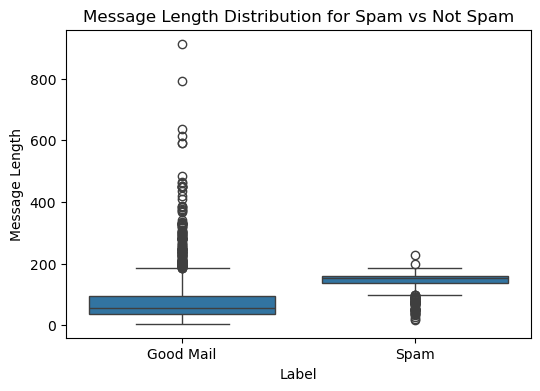

<Figure size 640x480 with 0 Axes>

In [36]:
# Visualize message length distribution for spam vs not spam
df2['message_length'] = df2['Email'].apply(len)

plt.figure(figsize=(6, 4))
sns.boxplot(x='Label', y='message_length', data=df2)
plt.title('Message Length Distribution for Spam vs Not Spam')
plt.xlabel('Label')
plt.ylabel('Message Length')
plt.show()
plt.savefig('message_length_distribution.png')

### Data Splitting 

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

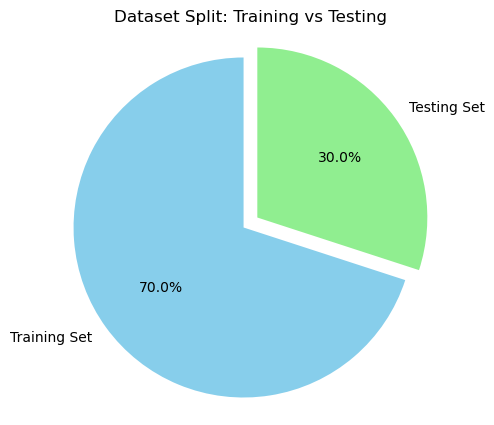

In [38]:
# Visualize dataset split using a pie chart
train_size = len(X_train)
test_size = len(X_test)

sizes = [train_size, test_size]
labels = ['Training Set', 'Testing Set']
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(6, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))
plt.title('Dataset Split: Training vs Testing')
plt.axis('equal') 
plt.savefig('dataset_split_pie_chart.png')
plt.show()

 ## Checking And Handling Class Imbalance 

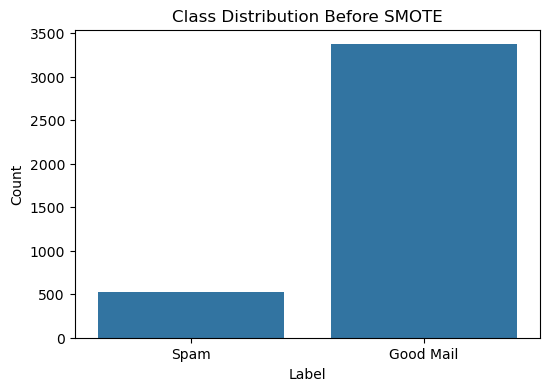

In [39]:
# Visualize class distribution before SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [40]:
# Handling class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

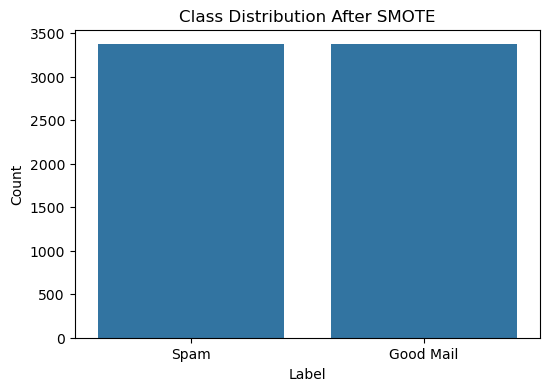

In [41]:
# Visualize class distribution after SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Naive Bayes Testing And Evaluation

In [42]:
nb_model = MultinomialNB()
history = nb_model.fit(X_train_smote, y_train_smote)

In [43]:
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred))


Naive Bayes Classification Report:
              precision    recall  f1-score   support

   Good Mail       0.99      0.97      0.98      1453
        Spam       0.82      0.92      0.86       219

    accuracy                           0.96      1672
   macro avg       0.90      0.94      0.92      1672
weighted avg       0.97      0.96      0.96      1672



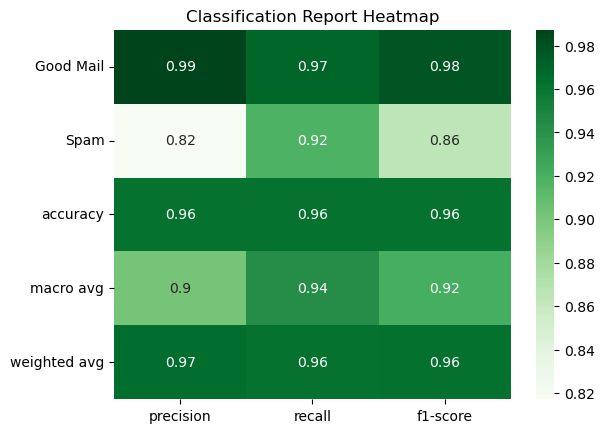

In [52]:
sns.heatmap(df_report[['precision','recall','f1-score']], annot=True, cmap="Greens")
plt.title("Classification Report Heatmap")
plt.show()


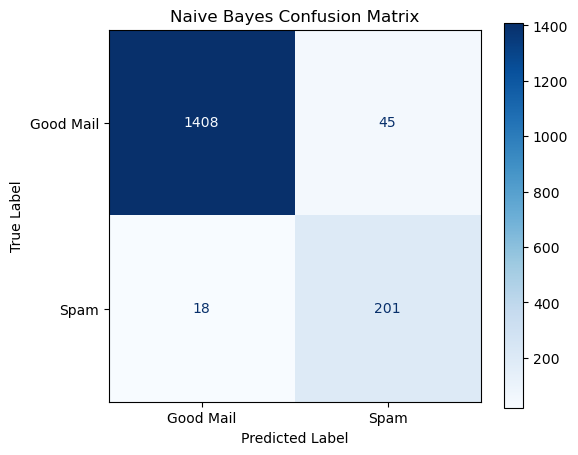

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
class_names = ['Good Mail', 'Spam']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


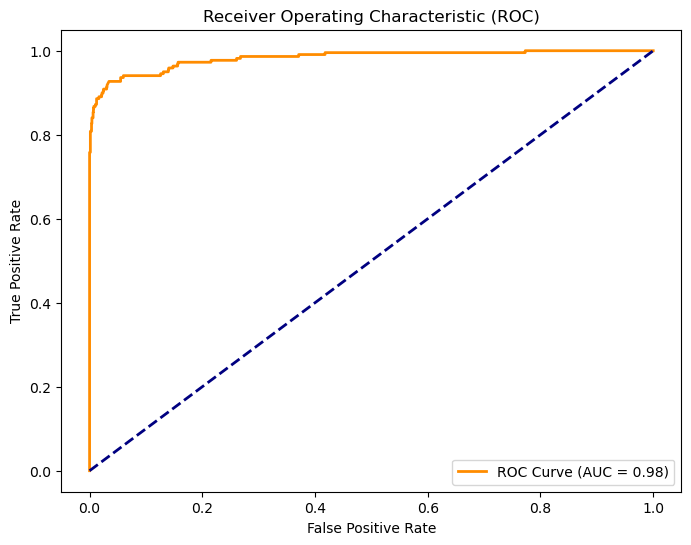

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label='Spam')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from joblib import dump

# Save model and vectorizer
dump(nb_model, "spam_model.joblib")
dump(vectorizer, "vectorizer.joblib")

['vectorizer.joblib']